In [45]:
import numpy as np
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
from sklearn.model_selection import train_test_split

In [5]:
!pip install kagglehub

In [6]:
#Obtenemos las imagens que formaran nuestra base de datos, descargando desde kaggle mediante path
import kagglehub
path = kagglehub.dataset_download(
    "bhavikjikadara/dog-and-cat-classification-dataset"
)

print("Ruta del dataset:", path)
print(os.listdir(path))



100%|██████████| 775M/775M [00:30<00:00, 27.0MB/s]

Extracting files...


Ruta del dataset: /root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1
['PetImages']


In [7]:
#Ahora definimos las rutas, y vemso cuantos datos contiene cada set
ruta_base=os.path.join(path,"PetImages")
ruta_gatos=os.path.join(ruta_base,"Cat")
ruta_perros=os.path.join(ruta_base,"Dog")
print("Gatos:", len(os.listdir(ruta_gatos)))
print("Perros:", len(os.listdir(ruta_perros)))


Gatos: 12499
Perros: 12499


In [8]:
#Preparamos los datos como la vez anterior probaremos con 250 gatos y 250 perros
np.random.seed(1)
random.seed(1)

n_por_clase=250

archivos_gatos=random.sample(os.listdir(ruta_gatos),n_por_clase)
archivos_perros=random.sample(os.listdir(ruta_perros),n_por_clase)

In [15]:
#Ahora cargamos las imagenes
X=[]
Y=[]
tamano=(64,64)

#Definimos para perros=0
for archivo in archivos_perros:
    ruta_img=os.path.join(ruta_perros,archivo)

    try:
        img=Image.open(ruta_img)
        img=img.convert("RGB")
        img=img.resize(tamano)

        img=np.array(img)/255

        X.append(img)
        Y.append(0)
    except:
        print("No se pudo cargar:", archivo)

#Toca definir gatos=1
for archivo in archivos_gatos:
    ruta_img=os.path.join(ruta_gatos,archivo)

    try:
        img=Image.open(ruta_img)
        img=img.convert("RGB")
        img=img.resize(tamano)

        img=np.array(img)/255

        X.append(img)
        Y.append(1)

    except:
        print("No se pudo cargar:", archivo)




In [16]:
#Creamos el arreglo
X=np.array(X)
Y=np.array(Y)
print("X:", X.shape)
print("Y:", Y.shape)


X: (500, 64, 64, 3)
Y: (500,)


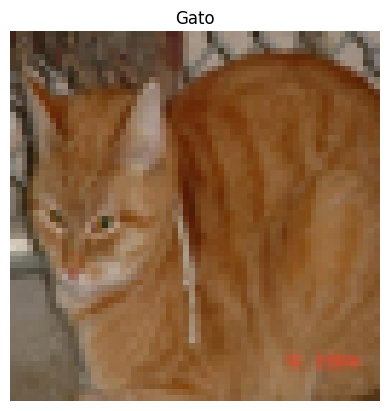

In [31]:
#Checamos que este tomando imagenes de maneri aleatoria

index =300

img = X[index]

plt.imshow(img)

if Y[index] == 1:
    plt.title("Gato")
else:
    plt.title("Perro")

plt.axis("off")
plt.show()

In [37]:
#Toca separar las imagenes entre entrenamiento y prueba

#Para sklearn necesitamoa aplanar nuestras imagenes,mientras que para tensor flow
# podmos mantener el formato imagen asi que creremos variables de separacions individuales
# para estos dos

#Tensor flow
X_train_img, X_test_img, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1, stratify=Y)
print("X_train_img:", X_train_img.shape)
print("X_test_img:", X_test_img.shape)
print("y_train:", Y_train.shape)
print("y_test:", Y_test.shape)
#Sklearn
X_train_flat=X_train_img.reshape(X_train_img.shape[0],-1)
X_test_flat=X_test_img.reshape(X_test_img.shape[0],-1)
print("X_train_flat:", X_train_flat.shape)
print("X_test_flat:", X_test_flat.shape)




X_train_img: (400, 64, 64, 3)
X_test_img: (100, 64, 64, 3)
y_train: (400,)
y_test: (100,)
X_train_flat: (400, 12288)
X_test_flat: (100, 12288)


Sklearn

In [38]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [39]:
#Aqui definimos el modelos de clasificacion , que directamente por la fucniones que se normaliza
modelo_clas_sklearn = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=1
    ))
])


In [40]:
#Entrenamos
modelo_clas_sklearn.fit(X_train_flat, Y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500,
                               random_state=1))])

In [41]:
#Ahora sacamos la prediccion
Y_pred_sklearn=modelo_clas_sklearn.predict(X_test_flat)
acc_sklearn=accuracy_score(Y_test, Y_pred_sklearn)
print("Accuracy:", acc_sklearn)
print(classification_report(Y_test, Y_pred_sklearn,target_names=['Perro','Gato']))

Accuracy: 0.6
              precision    recall  f1-score   support

       Perro       0.60      0.60      0.60        50
        Gato       0.60      0.60      0.60        50

    accuracy                           0.60       100
   macro avg       0.60      0.60      0.60       100
weighted avg       0.60      0.60      0.60       100



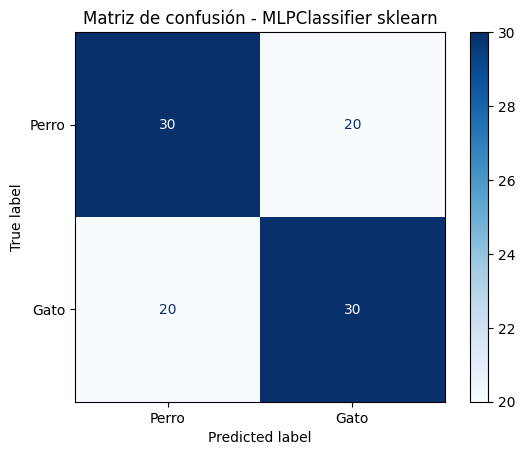

In [42]:
#Ahora veamos como queda la matriz de confusion
cm=confusion_matrix(Y_test, Y_pred_sklearn)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Perro','Gato'])
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - MLPClassifier sklearn")
plt.show()

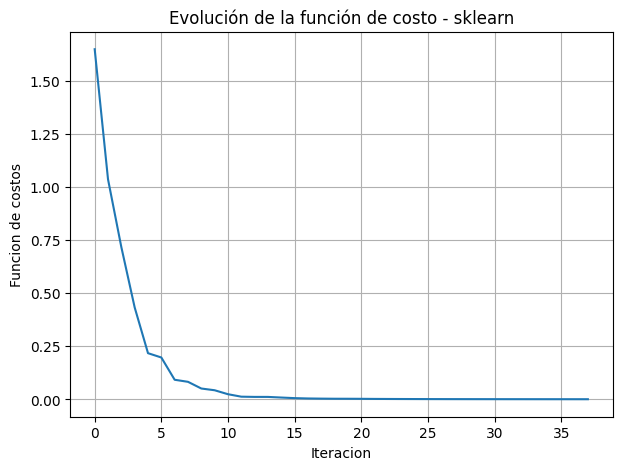

In [44]:
#Graficamos como se fue comportando la funcion de perdida

plt.figure(figsize=(7, 5))
plt.plot(modelo_clas_sklearn.named_steps["mlp"].loss_curve_)
plt.xlabel('Iteracion')
plt.ylabel('Funcion de costos')
plt.title('Evolución de la función de costo - sklearn')
plt.grid(True)
plt.show()

Tensor Flow

In [46]:
import tensorflow as tf

In [47]:
#Para Tensor Flow tomamos como ejemplor el usado en MINST, ahi trabajan con 10 clase aca solo tenemos dos
# Perro=0 y Gato=1

#Verificamos la forma de los dato
print("X_train_img:", X_train_img.shape)
print("X_test_img:", X_test_img.shape)
print("y_train:", Y_train.shape)
print("y_test:", Y_test.shape)

X_train_img: (400, 64, 64, 3)
X_test_img: (100, 64, 64, 3)
y_train: (400,)
y_test: (100,)


In [49]:
#Ahora hacemos una red neuronal sencilla, definimos el modelo por la funcion de tensor flow
modelo_tf_clas=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(64,64,3)),
    tf.keras.layers.Dense(128,activation="relu"), #128 neurona
    tf.keras.layers.Dense(64,activation="relu"),  #64 neuronas
    tf.keras.layers.Dense(1,activation="sigmoid") #Una salida
])

#Vemos el resumen

modelo_tf_clas.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#Ahora le decimos a TensorFlow que funcion de perdida usar y que optimizador usar:
modelo_tf_clas.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [51]:
#Guardamps los pesos iniciales
pesos_iniciales_tf=modelo_tf_clas.get_weights()
print('Numero de arreglos de peso:', len(pesos_iniciales_tf))

for i, p in enumerate(pesos_iniciales_tf):
  print(i, p.shape)


Numero de arreglos de peso: 6
0 (12288, 128)
1 (128,)
2 (128, 64)
3 (64,)
4 (64, 1)
5 (1,)


In [52]:
#Ahora si entrenamos, por ahora usamos la test como validacion despues podemos separar segun yo
history_clas=modelo_tf_clas.fit(
    X_train_img,
    Y_train,
    validation_data=(X_test_img,Y_test),
    batch_size=32,
    epochs=20)


Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5075 - loss: 1.3974 - val_accuracy: 0.4800 - val_loss: 0.7610
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5350 - loss: 0.7406 - val_accuracy: 0.5200 - val_loss: 0.7532
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5600 - loss: 0.7692 - val_accuracy: 0.5800 - val_loss: 0.6481
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5450 - loss: 0.7703 - val_accuracy: 0.5100 - val_loss: 1.0488
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6025 - loss: 0.7344 - val_accuracy: 0.5500 - val_loss: 0.7262
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6850 - loss: 0.5911 - val_accuracy: 0.5800 - val_loss: 0.6678
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6850 - loss: 0.5904 - val_accuracy: 0.6200 - val_loss: 0.6830
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7000 - loss: 0.5675 - val_accuracy: 0.5600 - v

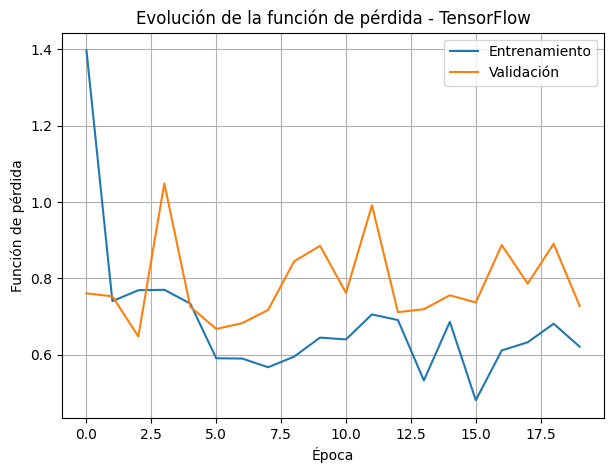

In [53]:
#Ahora graficamos la funcion de perdida
plt.figure(figsize=(7,5))

plt.plot(history_clas.history["loss"], label="Entrenamiento")
plt.plot(history_clas.history["val_loss"], label="Validación")

plt.xlabel("Época")
plt.ylabel("Función de pérdida")
plt.title("Evolución de la función de pérdida - TensorFlow")
plt.legend()
plt.grid(True)
plt.show()

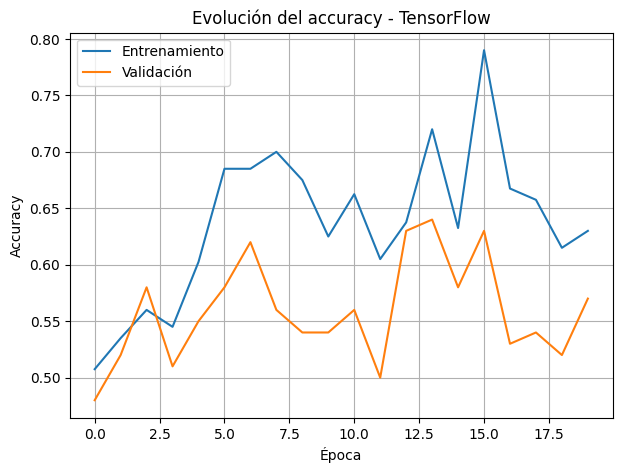

In [54]:
#Graficamos el Accuracy
plt.figure(figsize=(7,5))

plt.plot(history_clas.history["accuracy"], label="Entrenamiento")
plt.plot(history_clas.history["val_accuracy"], label="Validación")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución del accuracy - TensorFlow")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
#Sacamos la prediccion
prob_tf = modelo_tf_clas.predict(X_test_img)
Y_pred_tf = (prob_tf >= 0.5).astype(int).reshape(-1)

acc_tf = accuracy_score(Y_test, Y_pred_tf)

print("Accuracy TensorFlow:", acc_tf)
print(classification_report(Y_test, Y_pred_tf, target_names=["Perro", "Gato"]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Accuracy TensorFlow: 0.57
              precision    recall  f1-score   support

       Perro       0.67      0.28      0.39        50
        Gato       0.54      0.86      0.67        50

    accuracy                           0.57       100
   macro avg       0.61      0.57      0.53       100
weighted avg       0.61      0.57      0.53       100



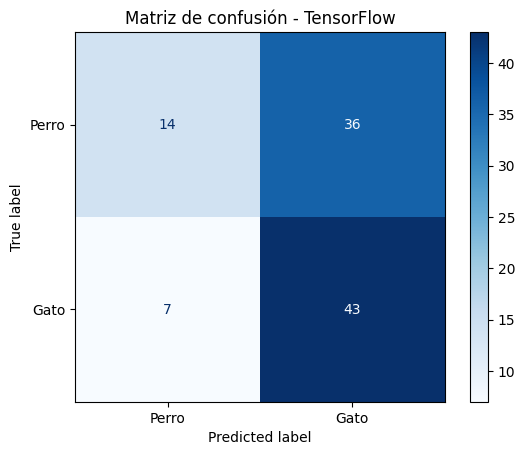

In [56]:
#La matriz de confusion
cm = confusion_matrix(Y_test, Y_pred_tf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Perro", "Gato"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - TensorFlow")
plt.show()